### 하이퍼파라미터
* 예측력을 높이기 위해 사용
* 과대/과소 적합을 방지하기 위해 사용
* 사용자가 지정하는 파라미터

#### 하이퍼파라미터 튜닝
* 특정 알고리즘의 매개변수 값을 변경하면서 최적의 파라미터를 찾는 방식
* GridSearchCV클래스를 통해 하이퍼파라미터 탐색과 교차 검증을 한번에 수행

#### GridSearchCV
* 교차 검증으로 하이퍼파라미터 탐색을 수행한다
* 최상의 모델을 찾은 후 훈련 세트 전체를 사용해 최종 모델을 훈련한다
* 매개변수
    - GridSearchCV(모델, param_grid = 파라미터, cv=반복횟수, n_jobs=코어 수(-1, 모든 코어 사용))

### K-최근접 이웃 알고리즘
* 주위에서 가장 가까운 다른 데이터를 보고 현재 데이터를 판단

#### 하이퍼파라미터
* n_neighbors
    - 기본 가까운 5개의 데이터를 보고 자기 자신이 어디에 속하는지를 판단
    - 비교하고자 하는 데이터의 수가 적을 수록 과대 적합이 된다
* metric : 거리계산 척도
    - euclidean(녹색) : 유클리디안 거리 측정
        * 목표 지점까지 가장 짧은 거리
        * 유클리디안은 일반적인 연속형 데이터에 적합
    - manhattan(빨간색) : 맨하튼 거리 측정 방법
        * 찾아가는 경로의 모든 길이의 합
        * 맨하탄 거리는 이상치 영향을 줄이고 싶을 때 사용
* weights : 가중치
    - uniform : 거리에 가중치 부여하지 않음(균일한 가중치)
    - distance : 거리에 가중치 부여(가까이 있는 데이터에 가중치)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data_set/5.스케일링/titanic_cleaning.csv")
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare'],
      dtype='object')

In [7]:
f = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch','Fare']
label = 'Survived'
X, y = df[f], df[label]

In [9]:
minMaxScaler = MinMaxScaler()
minMaxScaler.fit( X )
X_scaler = minMaxScaler.transform( X )
X_scaler

array([[1.        , 0.        , 0.27117366, 0.125     , 0.        ,
        0.01415106],
       [0.        , 1.        , 0.4722292 , 0.125     , 0.        ,
        0.13913574],
       [1.        , 1.        , 0.32143755, 0.        , 0.        ,
        0.01546857],
       ...,
       [1.        , 1.        , 0.36792055, 0.125     , 0.33333333,
        0.04577135],
       [0.        , 0.        , 0.32143755, 0.        , 0.        ,
        0.0585561 ],
       [1.        , 0.        , 0.39683338, 0.        , 0.        ,
        0.01512699]], shape=(891, 6))

In [10]:
X_train, X_test, y_train, y_test = train_test_split( X_scaler, y, test_size = 0.2 )

In [12]:
knn = KNeighborsClassifier()
knn.fit( X_train , y_train )
print("train : ", knn.score( X_train , y_train ) )
print("test : ", knn.score( X_test , y_test ) )

train :  0.8693820224719101
test :  0.7932960893854749


In [16]:
k_param = range(1, 11)
k_param
train_list = []
test_list = []

for k in k_param:
    #print( k )
    knn = KNeighborsClassifier( n_neighbors = k )
    knn.fit( X_train, y_train )
    train_score = knn.score( X_train, y_train )
    test_score = knn.score( X_test, y_test )
    train_list.append( train_score )
    test_list.append( test_score )

In [19]:
print(train_list)
print(test_list)

[0.976123595505618, 0.8946629213483146, 0.8834269662921348, 0.875, 0.8693820224719101, 0.8623595505617978, 0.851123595505618, 0.8469101123595506, 0.8441011235955056, 0.8286516853932584]
[0.7877094972067039, 0.8100558659217877, 0.7988826815642458, 0.8100558659217877, 0.7932960893854749, 0.8156424581005587, 0.7932960893854749, 0.7653631284916201, 0.7653631284916201, 0.7430167597765364]


In [21]:
dic = {
    "k": k_param,
    "train정확도": train_list,
    "test정확도": test_list
}
score_df = pd.DataFrame( dic )
score_df

,k,train정확도,test정확도
0,1,0.976124,0.787709
1,2,0.894663,0.810056
2,3,0.883427,0.798883
3,4,0.875000,0.810056
4,5,0.869382,0.793296
5,6,0.862360,0.815642
6,7,0.851124,0.793296
7,8,0.846910,0.765363
8,9,0.844101,0.765363
9,10,0.828652,0.743017


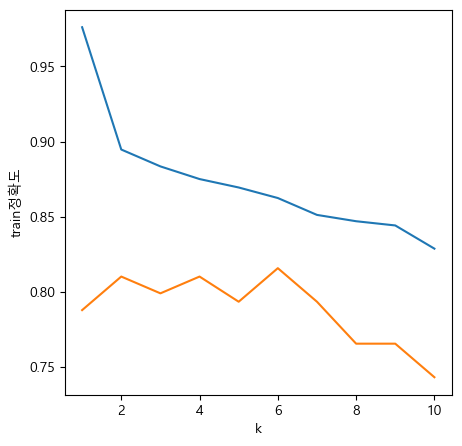

In [30]:
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots( figsize=(5,5))
sns.lineplot( x='k', y='train정확도', data=score_df)
sns.lineplot( x='k', y='test정확도', data=score_df)
plt.show()

In [32]:
params = {
    'n_neighbors':k_param
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV( knn, param_grid = params, cv = 5, n_jobs = -1)

In [33]:
grid_cv.fit( X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(1, 11)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [34]:
grid_cv.best_params_

{'n_neighbors': 4}

In [35]:
print("train score : ", grid_cv.score(X_train , y_train ) )
print("test score : ", grid_cv.score(X_test , y_test ) )

train score :  0.875
test score :  0.8100558659217877


In [36]:
params = {
    'n_neighbors':k_param,
    'metric': ['manhattan','euclidean'],
    'weights':['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV( knn, param_grid = params, cv = 5, n_jobs = -1)

In [38]:
grid_cv.fit( X_train, y_train)
print("train score : ", grid_cv.score(X_train , y_train ) )
print("test score : ", grid_cv.score(X_test , y_test ) )
grid_cv.best_params_

train score :  0.875
test score :  0.8100558659217877


{'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'uniform'}

In [39]:
knn = KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights= 'uniform')

In [40]:
knn.fit( X_train , y_train )
print("train score : ", knn.score(X_train , y_train ) )
print("test score : ", knn.score(X_test , y_test ) )

train score :  0.875
test score :  0.8100558659217877
